In [33]:
import pandas as pd
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error, r2_score


import os
from multiprocessing import Process


os.makedirs("../results/experiment_15_v2", exist_ok=True)

In [34]:
dataset = pd.read_csv("../dataset/riemann_features.csv")

features = pd.read_csv("../results/data_analysis/selected_features.csv")["feature"].tolist()

X = dataset.drop(columns=["distance"])
y = dataset["distance"]

X = X[:2000]
y = y[:2000]

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1600, 94) (1600,)
(400, 94) (400,)


# Classical SVR

In [35]:
def run_classical_experiment():
    results = []

    param_grid = {
        "svr__C": [0.1, 1, 5, 10],
        "svr__epsilon": [0.001, 0.01, 0.1, 0.5],
        "svr__gamma": ["scale", 0.01, 0.1, 1.0]
    }

    n_features = [i for i in range(1, 11)]

    for n in n_features:
        print(f"Running experiment for group: Rank Aggregation with {n} features")

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        pipeline = Pipeline([
            ("scaler", MinMaxScaler()),
            ("svr", SVR(kernel="rbf"))
        ])

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
            n_jobs=-1
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_

        y_pred = best_model.predict(X_test_subset)

        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append({
            "RMSE": rmse,
            "R2": r2,
            "Best C": grid.best_params_["svr__C"],
            "Best epsilon": grid.best_params_["svr__epsilon"],
            "Best gamma": grid.best_params_["svr__gamma"],
            "Features": n
        })

    results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v2/classical_experiment_results.csv", index=False)


In [36]:
run_classical_experiment()

Running experiment for group: Rank Aggregation with 1 features
Running experiment for group: Rank Aggregation with 2 features
Running experiment for group: Rank Aggregation with 3 features
Running experiment for group: Rank Aggregation with 4 features
Running experiment for group: Rank Aggregation with 5 features
Running experiment for group: Rank Aggregation with 6 features
Running experiment for group: Rank Aggregation with 7 features
Running experiment for group: Rank Aggregation with 8 features
Running experiment for group: Rank Aggregation with 9 features
Running experiment for group: Rank Aggregation with 10 features
       RMSE        R2  Best C  Best epsilon Best gamma  Features
0  0.057858  0.958818    10.0         0.001      scale         9
1  0.064620  0.948630    10.0         0.010      scale         6
2  0.070828  0.938285     5.0         0.001      scale        10
3  0.070840  0.938264    10.0         0.001      scale         8
4  0.072945  0.934541    10.0         0.001 

# Quantum SVR - DoubleAngleEntangledFeatureMap

In [37]:
def feature_map(x, wires, rotation_first="X", rotation_second="Y"):
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_first)
    qml.BasicEntanglerLayers(
        weights=np.zeros((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_second)


def make_simple_kernel(n_qubits, rotation_first="X", rotation_second="Y"):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map(x1, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        qml.adjoint(feature_map)(x2, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

In [38]:
def feature_map_v2(x, wires, rotation_first="X", rotation_second="Y"):
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_first)
    qml.BasicEntanglerLayers(
        weights=np.ones((1, len(wires))),
        wires=wires,
        rotation=qml.RZ
    )
    qml.AngleEmbedding(x, wires=wires, rotation=rotation_second)


def make_simple_kernel_v2(n_qubits, rotation_first="X", rotation_second="Y"):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)
        feature_map_v2(x1, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        qml.adjoint(feature_map_v2)(x2, wires=wires, rotation_first=rotation_first, rotation_second=rotation_second)
        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## DoubleAngleEntangledFeatureMap Circuit

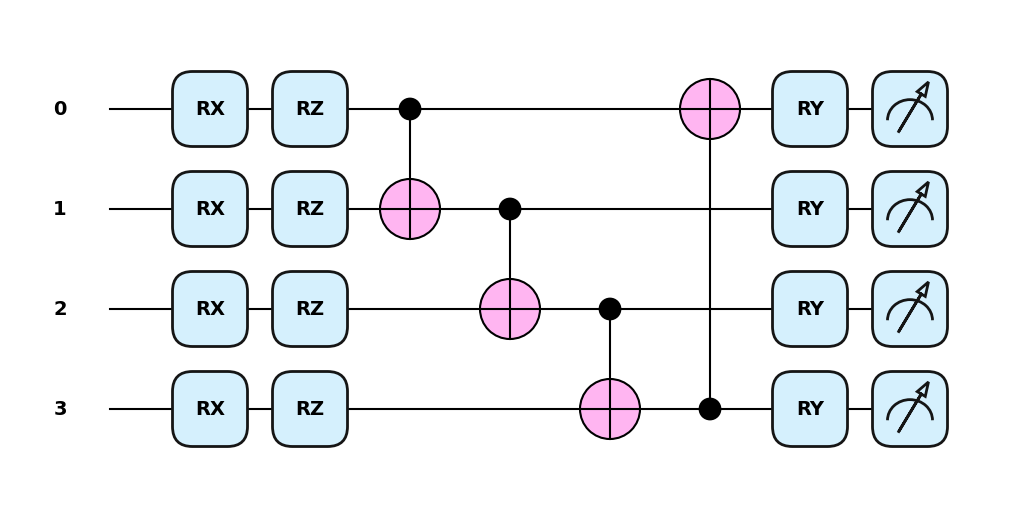

In [39]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    feature_map(x, wires=range(n_qubits), rotation_first="X", rotation_second="Y")
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v2/double_angle_entangled_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

# Quantum SVR - EntangledPolynomialFeatureMap

In [40]:
def enhanced_feature_map(x, wires, reps=1):
    for _ in range(reps):
        qml.AngleEmbedding(x, wires=wires, rotation="X")
        qml.AngleEmbedding(x, wires=wires, rotation="Z")

        for i in range(len(wires)):
            for j in range(i + 1, len(wires)):
                qml.IsingZZ(x[i] * x[j], wires=[wires[i], wires[j]])

        qml.AngleEmbedding(x, wires=wires, rotation="Y")


def make_enhanced_kernel(n_qubits, reps=1):
    dev = qml.device("lightning.qubit", wires=n_qubits)

    @qml.qnode(dev)
    def kernel_fn(x1, x2):
        wires = range(n_qubits)

        enhanced_feature_map(x1, wires=wires, reps=reps)
        qml.adjoint(enhanced_feature_map)(x2, wires=wires, reps=reps)

        return qml.expval(qml.Projector([0] * n_qubits, wires=wires))

    return kernel_fn

## EntangledPolynomialFeatureMap - Circuit

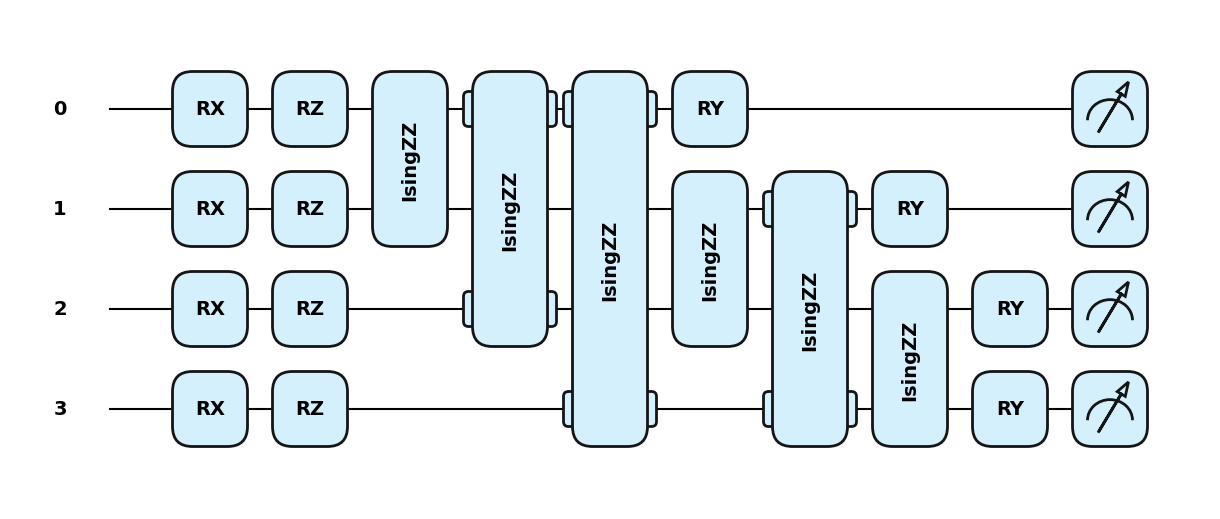

In [41]:
n_qubits = 4
x_example = np.random.uniform(0, np.pi, n_qubits)

dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def encoding_circuit(x):
    enhanced_feature_map(x, wires=range(n_qubits))
    return qml.state()


fig, ax = qml.draw_mpl(
    encoding_circuit,
    style="pennylane",
    level="device"
)(x_example)

plt.savefig("../results/experiment_15_v2/enhanced_feature_map.png", dpi=160, bbox_inches='tight')
plt.show()

In [42]:
def run_simple_experiment():
    n_qubits = [6, 9, 10]
    results = []
    kernels = {
        "6_YY":  (make_simple_kernel(6, rotation_first="Y", rotation_second="Y"), 6),
        "6_XY":  (make_simple_kernel(6, rotation_first="X", rotation_second="Y"), 6),
        "9_XY":  (make_simple_kernel(9, rotation_first="X", rotation_second="Y"), 9),
        "9_YY":  (make_simple_kernel(9, rotation_first="Y", rotation_second="Y"), 9),
        "10_YY": (make_simple_kernel(10, rotation_first="Y", rotation_second="Y"), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v2/simple_experiment_results.csv", index=False)


In [46]:
def run_simple_experiment_v2():
    n_qubits = [6, 9, 10]
    results = []
    kernels = {
        "6_YY_v2":  (make_simple_kernel_v2(6, rotation_first="Y", rotation_second="Y"), 6),
        "6_XY_v2":  (make_simple_kernel_v2(6, rotation_first="X", rotation_second="Y"), 6),
        "9_XY_v2":  (make_simple_kernel_v2(9, rotation_first="X", rotation_second="Y"), 9),
        "9_YY_v2":  (make_simple_kernel_v2(9, rotation_first="Y", rotation_second="Y"), 9),
        "10_YY_v2": (make_simple_kernel_v2(10, rotation_first="Y", rotation_second="Y"), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })

    results_df = pd.DataFrame(results)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v2/simple_experiment_results_v2.csv", index=False)


In [44]:
def run_enhanced_experiment():
    results = []
    kernels = {
        "6_enhanced":  (make_enhanced_kernel(6, 1), 6),
        "8_enhanced":  (make_enhanced_kernel(8, 1), 8),
        "9_enhanced":  (make_enhanced_kernel(9, 1), 9),
        "10_enhanced": (make_enhanced_kernel(10, 1), 10),
    }

    param_grid = {
        "svr__C": [1, 5],
        "svr__epsilon": [0.01, 0.1]
    }

    for name, (kernel, n) in kernels.items():
        print(f"Running kernel {name}")

        kernel_mat = lambda A, B, kf=kernel: qml.kernels.kernel_matrix(A, B, kf)

        pipeline = Pipeline([
            ("scaler", MinMaxScaler(feature_range=(0, np.pi))),
            ("svr", SVR(kernel=kernel_mat))
        ])

        X_train_subset = X_train[features[:n]].to_numpy()
        X_test_subset = X_test[features[:n]].to_numpy()

        grid = GridSearchCV(
            pipeline,
            param_grid,
            scoring="neg_root_mean_squared_error",
            cv=TimeSeriesSplit(n_splits=2),
        )

        grid.fit(X_train_subset, y_train)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test_subset)
        rmse = root_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Kernel: {name}, RMSE: {rmse:.4f}, R^2: {r2:.4f}")
        results.append({
            "kernel": name,
            "rmse": rmse,
            "r2": r2,
            "best_c": grid.best_params_["svr__C"],
            "best_epsilon": grid.best_params_["svr__epsilon"]
        })


    results_df = pd.DataFrame(results)
    print(results_df)
    results_df.to_csv("../results/experiment_15_v2/enhanced_experiment_results.csv", index=False)


In [47]:
p_simple_process = Process(target=run_simple_experiment)
p_simple_process_v2 = Process(target=run_simple_experiment_v2)
p_enhanced_process = Process(target=run_enhanced_experiment)

p_simple_process.start()
p_simple_process_v2.start()
p_enhanced_process.start()
p_simple_process.join()
p_simple_process_v2.join()
p_enhanced_process.join()

Running kernel 6_YY


Running kernel 6_YY_v2
Running kernel 6_enhanced
Kernel: 6_YY, RMSE: 0.0899, R^2: 0.9006
Running kernel 6_XY
Kernel: 6_YY_v2, RMSE: 0.0891, R^2: 0.9024
Running kernel 6_XY_v2
Kernel: 6_enhanced, RMSE: 0.0754, R^2: 0.9300
Running kernel 8_enhanced
Kernel: 6_XY, RMSE: 0.0887, R^2: 0.9032
Running kernel 9_XY
Kernel: 6_XY_v2, RMSE: 0.0893, R^2: 0.9019
Running kernel 9_XY_v2
Kernel: 8_enhanced, RMSE: 0.1051, R^2: 0.8641
Running kernel 9_enhanced
Kernel: 9_XY, RMSE: 0.0657, R^2: 0.9468
Running kernel 9_YY
Kernel: 9_XY_v2, RMSE: 0.0683, R^2: 0.9427
Running kernel 9_YY_v2
Kernel: 9_enhanced, RMSE: 0.1091, R^2: 0.8537
Running kernel 10_enhanced
Kernel: 9_YY, RMSE: 0.0697, R^2: 0.9403
Running kernel 10_YY
Kernel: 9_YY_v2, RMSE: 0.0665, R^2: 0.9456
Running kernel 10_YY_v2
Kernel: 10_YY, RMSE: 0.0772, R^2: 0.9266
  kernel      rmse        r2  best_c  best_epsilon
0   6_YY  0.089881  0.900615       5          0.01
1   6_XY  0.088694  0.903223       5          0.01
2   9_XY  0.065748  0.946820      